In [ ]:
#DEMAND FORECASTING

In [1]:
#IMPORTS LIBRARIES
# arrays and dataframes
import pandas as pd
import numpy as np

# visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# time series - statsmodels
from statsmodels.tsa.filters.hp_filter import hpfilter  # Hodrick Prescott filter for cyclic & trend separation
from statsmodels.tsa.seasonal import seasonal_decompose # Error Trend Seasonality decomposition

# holt winters 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   # single exponential smoothing as in ewm of pandas
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing

# consistent plot size wherever not specifiied
from pylab import rcParams
rcParams['figure.figsize'] = (12,5)
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['axes.labelsize'] = 12 

In [ ]:
#DEMAND COMPONENTS: Hodrick Prescott filter

In [2]:
# US Macro economic data
usmacro = pd.read_csv("C:/Users/Alexandra Logorio/HLM/Demand Forecasting/macrodata.csv",index_col=0,parse_dates=True)
usmacro.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


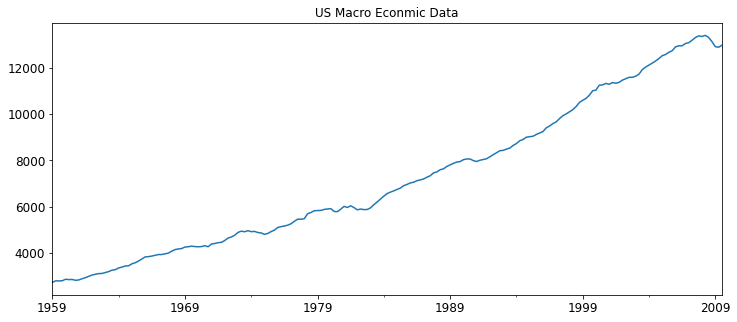

In [3]:
# visualize the realgdp --- > will use the capabilities of pandas plotting capability
usmacro['realgdp'].plot(figsize=(12,5),title='US Macro Econmic Data').autoscale(axis='x',tight=True)

In [4]:
# The trend and cycles can be separated using tuple unpacking according to Hodrick Prescott filter.
# Tuple unpacking with lambda as 1600 to analyze the quarterly trend 
cycles,trend = hpfilter(usmacro['realgdp'],lamb=1600) 

In [5]:
# We will add trend and cycles as additional columns in the data frame -- makes trend plotting easier with pandas
usmacro['gdp_trend'] = trend
usmacro['gdp_cycles'] = cycles

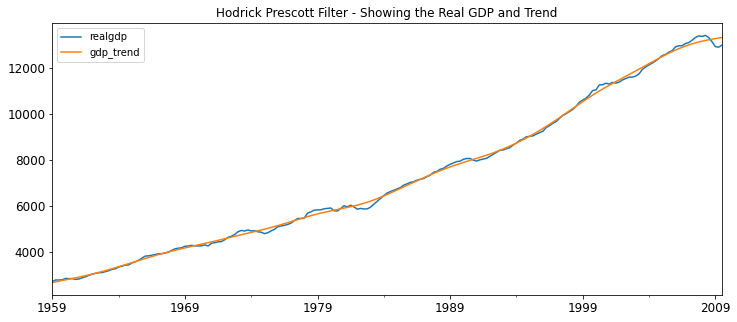

In [6]:
usmacro[['realgdp','gdp_trend']].plot(figsize=(12,5),title='Hodrick Prescott Filter - Showing the Real GDP and Trend').autoscale(axis='x',tight=True)

In [ ]:
#Now we have the GDP trend which is sensitive to the long term fluctuations and not to the short term fluctuations. 
#This makes more sense for analysing the business life cycle over a well defined period. 
#Similarly, the trend can be analyzed by varying the values of lambda to check for annual and monthly trend.

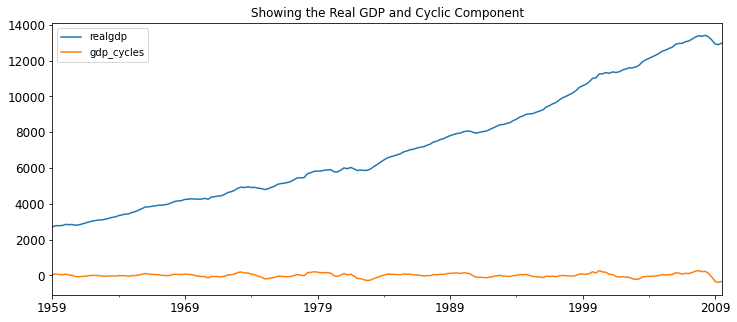

In [7]:
# Plot the cyclic component
usmacro[['realgdp','gdp_cycles']].plot(figsize=(12,5),title='Showing the Real GDP and Cyclic Component').autoscale(axis='x',tight=True)

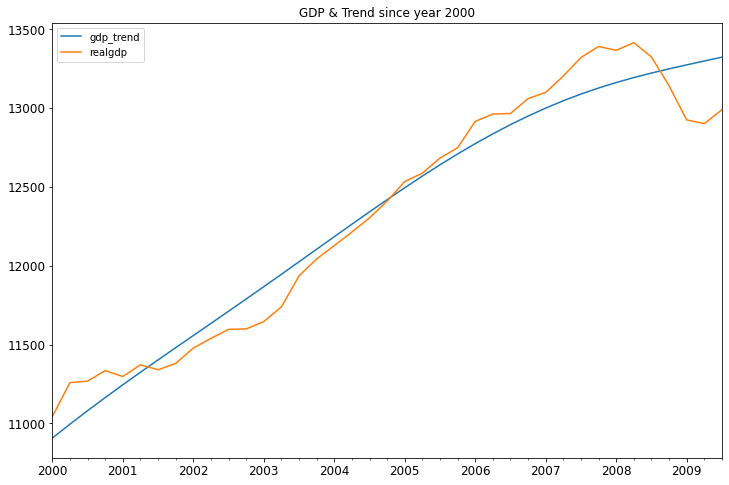

In [8]:
#Lets check this out since year 2000
usmacro[['gdp_trend','realgdp']]['2000-03-31':].plot(figsize=(12,8),title='GDP & Trend since year 2000').autoscale(axis='x',tight=True);

In [ ]:
#ERROR, TREND, SEASONALITY DECOMPOSITION

In [10]:
#The decomposition of a time series attempts to isolate individual components such as error, trend and seasonality. Statsmodels provided seasonal decomposition tool to separate out the different components.
#To demonstrate the seasonal decomposition capability of statsmodels, I will make use of the airline passenger data.
# Remember - Additive model is used when the trend component is more constant over time. 
#Example, every year 20,000 passengers are added. 
# Multiplicative model is used when the trend increases/decreases at a non linear rate. 
#Example, every year the number of airline passengers doubles by 20,000.

In [9]:
airline = pd.read_csv("C:/Users/Alexandra Logorio/HLM/Demand Forecasting/airline_passengers.csv",index_col='Month', parse_dates=True)
airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [11]:
# decompose the time series
decompose_result = seasonal_decompose(airline['Thousands of Passengers'],model='multiplicative')

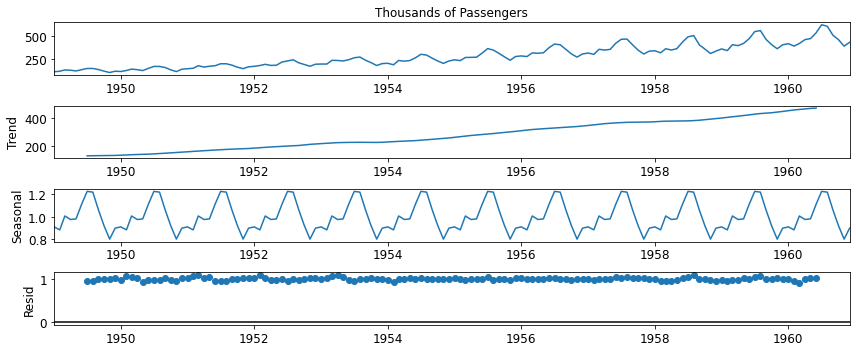

In [13]:
decompose_result.plot();

In [ ]:
#FORECAST MODELS

In [ ]:
#SMA - Simple Moving Averages

In [14]:
airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


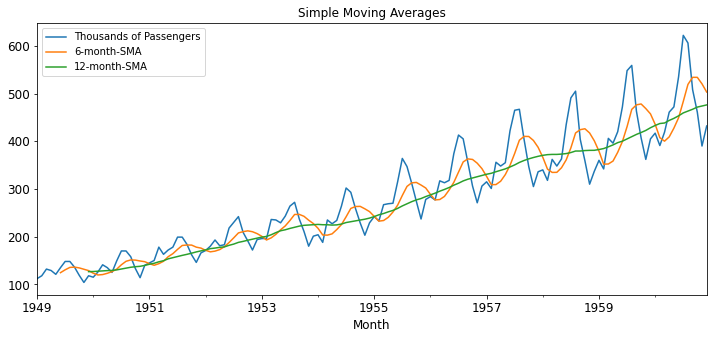

In [15]:
airline.dropna(inplace=True)
airline['6-month-SMA'] = airline['Thousands of Passengers'].rolling(window=6).mean()
airline['12-month-SMA'] = airline['Thousands of Passengers'].rolling(window=12).mean()
airline.plot(title='Simple Moving Averages');

In [16]:
airline.head(12) 

,Thousands of Passengers,6-month-SMA,12-month-SMA
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN
1949-06-01,135,124.500000,NaN
1949-07-01,148,130.500000,NaN
1949-08-01,148,135.500000,NaN
1949-09-01,136,136.166667,NaN


In [ ]:
#Note that rolling introduces the NaN depending on the window size selected. 
#However there are some disadvantages of simple moving average: smaller windows will lead to more noise, rather than signal.
#It will always lag by the size of the window (see the MA starts after a certain lag above in the figure)
#It will never reach to full peak or valley of the data due to the averaging.
#Does not really inform you about possible future behavior, all it really does is describe trends in your data.
#Extreme historical values can skew your SMA significantly
#To help fix some of these problems,To help fix some of these problems, we have the EWMA or the Exponentially Weighted Moving Averageand other more complex forecasting models.

In [28]:
airline.head()

,Thousands of Passengers,6-month-SMA,12-month-SMA,SES12
Month,,,,
1949-01-01,112,NaN,NaN,112.000000
1949-02-01,118,NaN,NaN,112.923077
1949-03-01,132,NaN,NaN,115.857988
1949-04-01,129,NaN,NaN,117.879836
1949-05-01,121,NaN,NaN,118.359861


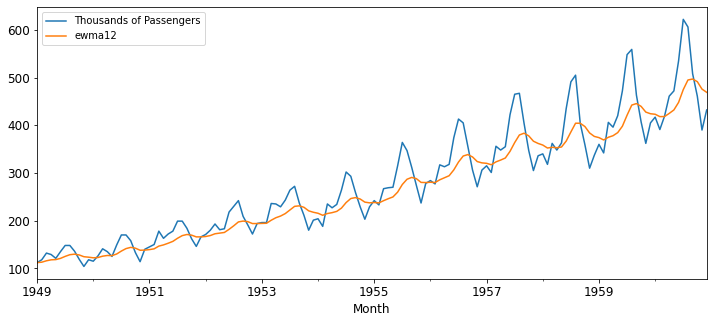

In [29]:
airline['ewma12'] = airline['Thousands of Passengers'].ewm(span=12,adjust=False).mean()
airline[['Thousands of Passengers','ewma12']].plot();

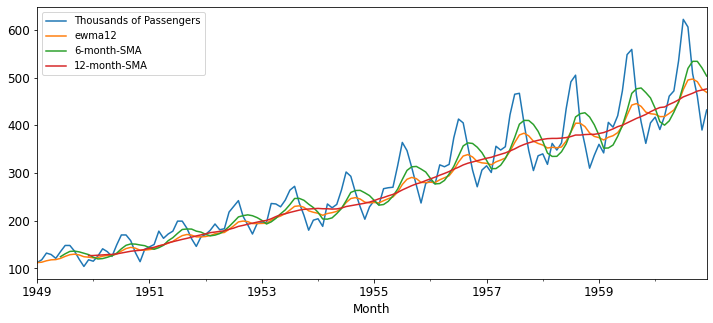

In [30]:
airline[['Thousands of Passengers','ewma12','6-month-SMA','12-month-SMA']].plot();

In [ ]:
#Single Exponential Smoothing, Holt's Model (double exponential smoothing) and Holt-Winter's model (triple exponential smoothing)

In [31]:
# set the span and the smoothing factor alpha.
#Span corresponds to what is commonly called an “N-day EW moving average”.Alpha specifies the smoothing factor directly.
#To work with forecasting models like Holt Winters, ARIMA, SARIMA etc., the datetime index frequency needs to be set. 
#The Airline passenger dataset index indicates dates on the start of the month. Hence we can set this as 'MS'
span = 12
alpha = 2/(span+1)
airline.columns
airline.index.freq = 'MS'
airline.head()
airline.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [ ]:
#Simple Exponential Smoothing

In [34]:
airline['SES12'] = SimpleExpSmoothing(airline['Thousands of Passengers']).fit(smoothing_level=alpha,optimized=False).fittedvalues.shift(-1)

In [35]:
airline.head()

,Thousands of Passengers,6-month-SMA,12-month-SMA,SES12,ewma12
Month,,,,,
1949-01-01,112,NaN,NaN,112.000000,112.000000
1949-02-01,118,NaN,NaN,112.923077,112.923077
1949-03-01,132,NaN,NaN,115.857988,115.857988
1949-04-01,129,NaN,NaN,117.879836,117.879836
1949-05-01,121,NaN,NaN,118.359861,118.359861


In [ ]:
#NOTE: For some reason, when optimized=False is passed into .fit(), the statsmodels SimpleExpSmoothing function shifts fitted values down one row. We fix this by adding .shift(-1) after .fittedvalues

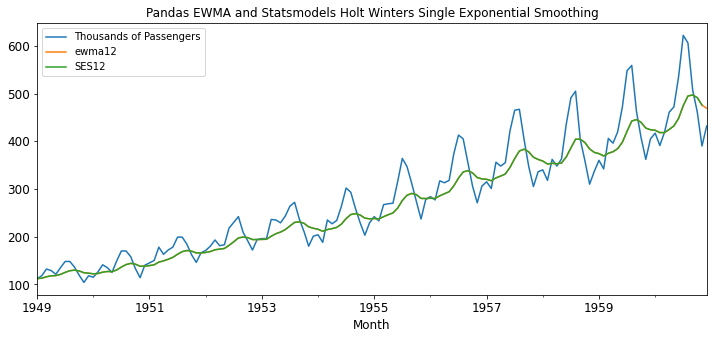

In [36]:
airline[['Thousands of Passengers','ewma12','SES12']].plot(title='Pandas EWMA and Statsmodels Holt Winters Single Exponential Smoothing');

In [ ]:
#Double Exponential Smoothing

In [40]:
airline['DES12'] = ExponentialSmoothing(airline['Thousands of Passengers'],trend='add').fit().fittedvalues.shift(-1)

C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:427: FutureWarning: After 0.13 initialization must be handled at model creation
  warnings.warn(


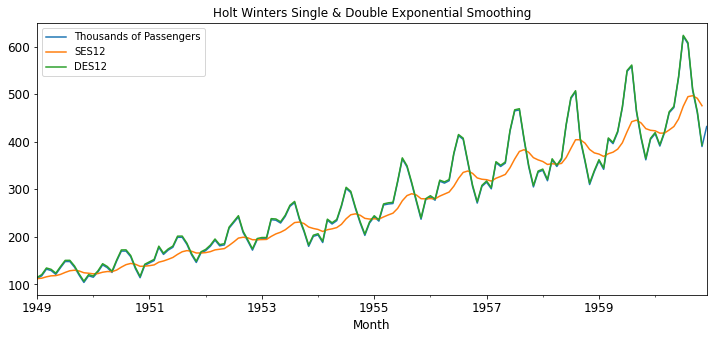

In [41]:
airline[['Thousands of Passengers','SES12','DES12']].plot(title='Holt Winters Single & Double Exponential Smoothing');

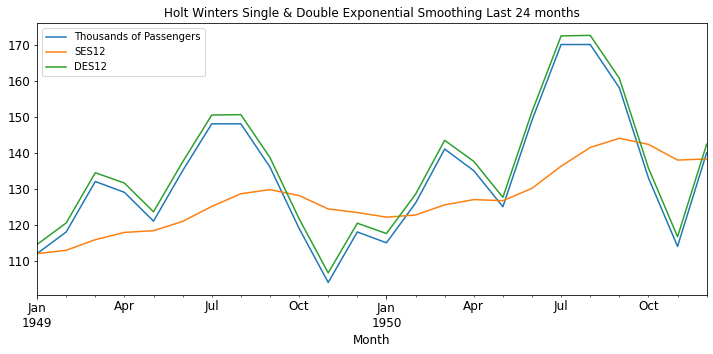

In [42]:
airline[['Thousands of Passengers','SES12','DES12']].iloc[:24].plot(title='Holt Winters Single & Double Exponential Smoothing Last 24 months').autoscale(axis='x',tight=True);

In [43]:
airline['DES12_mul'] = ExponentialSmoothing(airline['Thousands of Passengers'],trend='mul').fit().fittedvalues.shift(-1)

C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:427: FutureWarning: After 0.13 initialization must be handled at model creation
  warnings.warn(
C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:80: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


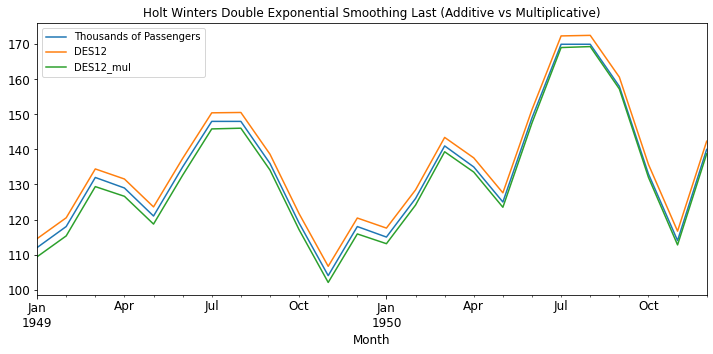

In [44]:
airline[['Thousands of Passengers','DES12','DES12_mul']].iloc[:24].plot(title='Holt Winters Double Exponential Smoothing Last (Additive vs Multiplicative)').autoscale(axis='x',tight=True);

In [ ]:
#Triple Exponential Smoothing

In [45]:
airline['TESadd12'] = ExponentialSmoothing(airline['Thousands of Passengers'],trend='add',seasonal='add',seasonal_periods=12).fit().fittedvalues

C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:427: FutureWarning: After 0.13 initialization must be handled at model creation
  warnings.warn(


In [46]:
airline.head()

,Thousands of Passengers,6-month-SMA,12-month-SMA,SES12,ewma12,DES12,DES12_mul,TESadd12
Month,,,,,,,,
1949-01-01,112,NaN,NaN,112.000000,112.000000,114.540770,109.374338,111.990507
1949-02-01,118,NaN,NaN,112.923077,112.923077,120.495273,115.328802,120.167888
1949-03-01,132,NaN,NaN,115.857988,115.857988,134.434351,129.393928,134.700831
1949-04-01,129,NaN,NaN,117.879836,117.879836,131.564469,126.630889,131.373211
1949-05-01,121,NaN,NaN,118.359861,118.359861,123.602997,118.706266,124.628127


In [47]:
airline['TESmul12'] = ExponentialSmoothing(airline['Thousands of Passengers'],trend='mul',seasonal='mul',seasonal_periods=12).fit().fittedvalues

C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:427: FutureWarning: After 0.13 initialization must be handled at model creation
  warnings.warn(
C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:80: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


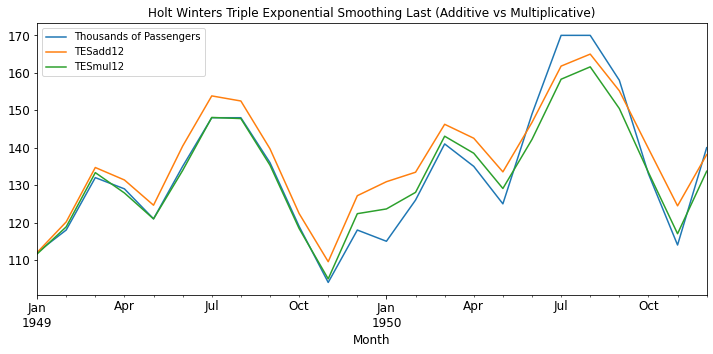

In [48]:
airline[['Thousands of Passengers','TESadd12','TESmul12']].iloc[:24].plot(title='Holt Winters Triple Exponential Smoothing Last (Additive vs Multiplicative)').autoscale(axis='x',tight=True);

In [ ]:
# Holt Winters Method

In [50]:
airline  = pd.read_csv("C:/Users/Alexandra Logorio/HLM/Demand Forecasting/airline_passengers.csv",index_col='Month',
                      parse_dates=True)

In [51]:
airline.index.freq = 'MS'

In [52]:
airline.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [53]:
airline.tail()

,Thousands of Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [54]:
# Number of months of data 
len(airline)

144

In [55]:
# Split into train and test set
train_airline = airline[:108] 
test_airline = airline[108:] 
len(test_airline)

36

In [56]:
fitted_model = ExponentialSmoothing(train_airline['Thousands of Passengers'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
test_predictions = fitted_model.forecast(36).rename('HW Test Forecast')
test_predictions[:10]

C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:427: FutureWarning: After 0.13 initialization must be handled at model creation
  warnings.warn(
C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:80: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\base\tsa_model.py:132: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  date_key = Timestamp(key, freq=base_index.freq)


1958-01-01    356.968589
1958-02-01    344.588770
1958-03-01    405.718306
1958-04-01    400.610808
1958-05-01    409.001662
1958-06-01    480.694216
1958-07-01    530.470082
1958-08-01    523.288574
1958-09-01    454.210582
1958-10-01    392.518096
Freq: MS, Name: HW Test Forecast, dtype: float64

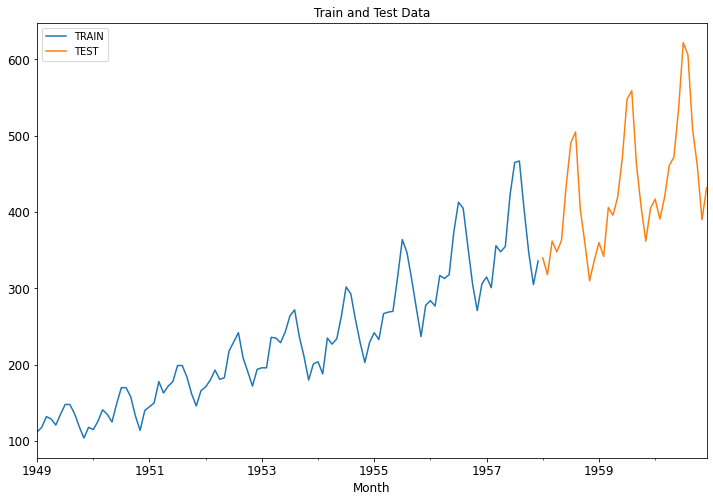

In [57]:
train_airline['Thousands of Passengers'].plot(legend=True,label='TRAIN')
test_airline['Thousands of Passengers'].plot(legend=True,label='TEST',figsize=(12,8))
plt.title('Train and Test Data');

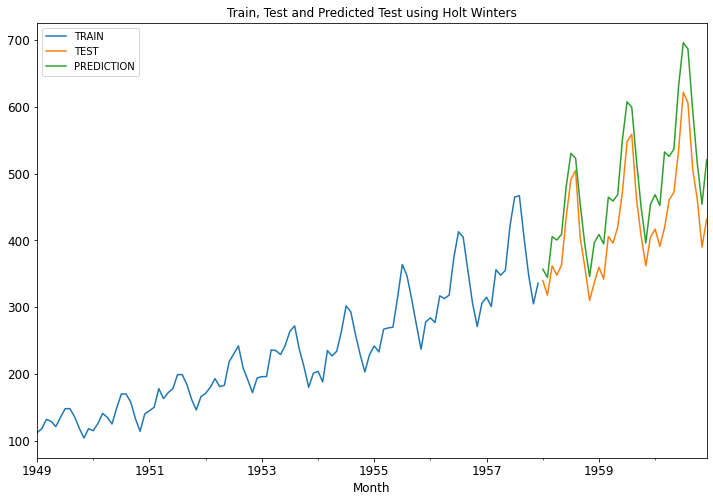

In [58]:
train_airline['Thousands of Passengers'].plot(legend=True,label='TRAIN')
test_airline['Thousands of Passengers'].plot(legend=True,label='TEST',figsize=(12,8))
test_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted Test using Holt Winters');

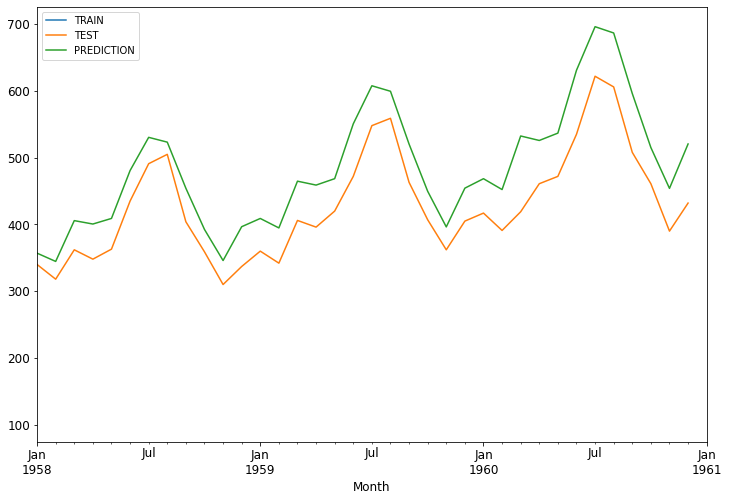

In [59]:
train_airline['Thousands of Passengers'].plot(legend=True,label='TRAIN')
test_airline['Thousands of Passengers'].plot(legend=True,label='TEST',figsize=(12,8))
test_predictions.plot(legend=True,label='PREDICTION',xlim=['1958-01-01','1961-01-01']);

In [ ]:
#Evaluation metrics

In [60]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(f'Mean Absolute Error = {mean_absolute_error(test_airline,test_predictions)}')

Mean Absolute Error = 55.698010020242464


In [61]:
print(f'Mean Squared Error = {mean_squared_error(test_airline,test_predictions)}')

Mean Squared Error = 3525.8917995273287


In [62]:
test_airline.describe()

,Thousands of Passengers
count,36.000000
mean,428.500000
std,79.329152
min,310.000000
25%,362.000000
50%,412.000000
75%,472.000000
max,622.000000


In [ ]:
#Forecast into the future

C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:427: FutureWarning: After 0.13 initialization must be handled at model creation
  warnings.warn(
C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\holtwinters\model.py:80: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Program Files\Anaconda\lib\site-packages\statsmodels\tsa\base\tsa_model.py:132: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  date_key = Timestamp(key, freq=base_index.freq)


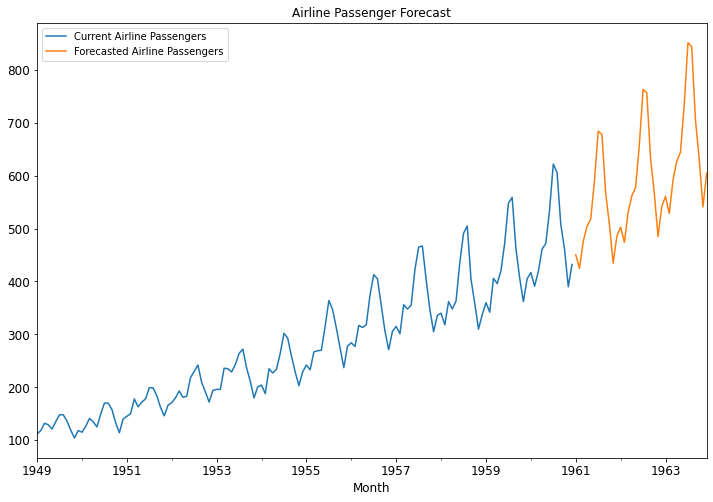

In [63]:
final_model = ExponentialSmoothing(airline['Thousands of Passengers'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
forecast_predictions = final_model.forecast(steps=36)
airline['Thousands of Passengers'].plot(figsize=(12,8),legend=True,label='Current Airline Passengers')
forecast_predictions.plot(legend=True,label='Forecasted Airline Passengers')
plt.title('Airline Passenger Forecast');